In [1]:
import sys
from pathlib import Path

# Main root of repo MSTT
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [39]:
import os
import time
import numpy as np
import torch
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score

import src.model
import src.training
import src.testing
from src.preprocess_data import all_preprocess

import torch.optim
import torch.nn as nn
from torch.utils.data import  DataLoader
from tqdm.auto import tqdm # Loading bar

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test, num_idx, cat_idx, cat_cardinalities, n_classes = all_preprocess(id=41143,
                                                                                                       seed=42,
                                                                                                       test_size=0.20,
                                                                                                       standardscaler_status=True)
print('X train shape: ', X_train.shape)
print('X val shape: ', X_val.shape)
print('X test shape: ', X_test.shape)
print('Index numerical features:', num_idx)
print('Index categorical features:', cat_idx)
print('Number of categories per feature:', cat_cardinalities)
print('Number of classes:', n_classes)

Dataset name:  jasmine
Columns with null values: []
Missing values:
Series([], dtype: float64)
Unique categories:  {'V1': 2, 'V2': 2, 'V3': 2, 'V4': 2, 'V5': 2, 'V6': 2, 'V7': 2, 'V8': 2, 'V9': 2, 'V10': 2, 'V11': 2, 'V12': 2, 'V14': 2, 'V15': 2, 'V16': 2, 'V17': 2, 'V18': 2, 'V19': 2, 'V20': 2, 'V21': 2, 'V22': 2, 'V24': 2, 'V25': 2, 'V26': 2, 'V27': 2, 'V28': 2, 'V29': 2, 'V30': 2, 'V31': 2, 'V32': 2, 'V33': 2, 'V34': 2, 'V35': 2, 'V36': 2, 'V37': 2, 'V38': 2, 'V39': 2, 'V40': 2, 'V41': 2, 'V42': 2, 'V44': 2, 'V46': 2, 'V47': 2, 'V48': 2, 'V49': 2, 'V50': 2, 'V51': 2, 'V52': 2, 'V53': 2, 'V54': 2, 'V55': 2, 'V57': 2, 'V58': 2, 'V60': 2, 'V61': 2, 'V62': 2, 'V63': 2, 'V64': 1, 'V65': 2, 'V66': 2, 'V67': 2, 'V68': 2, 'V69': 2, 'V70': 2, 'V71': 2, 'V72': 2, 'V73': 2, 'V74': 2, 'V75': 2, 'V76': 2, 'V77': 2, 'V78': 2, 'V79': 2, 'V80': 2, 'V81': 2, 'V82': 2, 'V83': 2, 'V84': 2, 'V85': 2, 'V86': 2, 'V87': 2, 'V88': 2, 'V89': 2, 'V90': 2, 'V91': 2, 'V92': 2, 'V93': 2, 'V94': 2, 'V95': 2, 'V9

In [4]:
#verify the number of numerical and/or categorical features
total_features = X_train.shape[1]
n_cont_features = len(num_idx)
n_categorical_features = len(cat_idx)
train_idx = X_train.shape[0]

In [5]:
# Have a dictionary with the data
# Create a dictionary with the data
data_numpy = {
    "train": {"y": y_train},
    "val": {"y": y_val},
    "test": {"y": y_test},
}

if n_cont_features != 0:
    data_numpy["train"]["x_cont"] = X_train[:, num_idx].astype(np.float32)
    data_numpy["val"]["x_cont"] = X_val[:, num_idx].astype(np.float32)
    data_numpy["test"]["x_cont"] = X_test[:, num_idx].astype(np.float32)

if n_categorical_features != 0:
    data_numpy["train"]["x_cat"] = (X_train[:, cat_idx]).astype(np.int64)
    data_numpy["val"]["x_cat"] = (X_val[:, cat_idx]).astype(np.int64)
    data_numpy["test"]["x_cat"] = (X_test[:, cat_idx]).astype(np.int64)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
if n_classes == 2:
    task_type = "binary"
    binary_class_state = True
else:
    task_type = "multiclass"
    binary_class_state = False

In [8]:
# >>> Convert data to tensors.
dataset = {
    part: {k: torch.as_tensor(v) for k, v in data_numpy[part].items()}
    for part in data_numpy
}

if task_type != "multiclass":
    # Required by F.binary_cross_entropy_with_logits
    for part in dataset:
        dataset[part]["y"] = dataset[part]["y"].float()

In [9]:
# The output size.
d_out = n_classes if task_type == "multiclass" else 1
d_out

1

In [10]:
config = dict(seed = 11,
              id =41157,
              d_model = 128,
              norm_standar_scaler = True,
              bias_st_cat = True,
              pos_norm = False,
              positional_encoding = False,
              div_positional_encoding = None,
              num_learned_features =[[12,12,13,13],[6,6,6,6],[3,3,3,3]],
              num_heads = 4,
              patience_early_stop = 20,
              hidden_dim_attmlp = 256,
              hidden_dim_supmlp = 64,
              learning_rate = 1e-4, #1e-3
              weight_decay = 1e-4,
              batch_size = 64,
              epochs = 60)

In [12]:
stt_model = src.model.MSTT(d_model = config['d_model'], 
                           cat_cardinalities = cat_cardinalities,
                           num_features = total_features, 
                           num_learned_features = config['num_learned_features'],
                           num_heads = config['num_heads'], 
                           hidden_dim_attmlp = config['d_model']*2,
                           hidden_dim_supmlp = config['hidden_dim_supmlp'], 
                           output_dim_supmlp = d_out,
                           device = device, 
                           divisor = config['div_positional_encoding'],
                           pos_norm = config['pos_norm'], 
                           positional_enc_status = config['positional_encoding'],
                           bias_st_cat = config['bias_st_cat']).to(device)

In [13]:
torch.manual_seed(config['seed'])     # para CPU

# Si usas GPU (CUDA)
if torch.cuda.is_available():
    torch.cuda.manual_seed(config['seed'])
    torch.cuda.manual_seed_all(config['seed'])  # si usas más de una GPU

# Opciones deterministas (importante)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [15]:
early_stopping = src.training.EarlyStopping(patience=config['patience_early_stop'], verbose=True)

In [ ]:
# Define optimizer
optimizer = torch.optim.AdamW(stt_model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'],betas=(0.9, 0.98))
#Define loss function
if task_type == "multiclass":
    criterion = nn.CrossEntropyLoss()
else:
    criterion = nn.BCEWithLogitsLoss()
print(criterion)

BCEWithLogitsLoss()


In [24]:
num_workers = min(4, os.cpu_count())
print("num_workers:", num_workers)

num_workers: 4


In [25]:
train_dataset = src.preprocess_data.CustomDictDataset(dataset['train'],binary_class=binary_class_state)
train_dataloader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True,
                              num_workers=num_workers,pin_memory=True)

test_dataset = src.preprocess_data.CustomDictDataset(dataset['test'],binary_class=binary_class_state)
test_dataloader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False,
                             num_workers=num_workers,pin_memory=True)

val_dataset = src.preprocess_data.CustomDictDataset(dataset['val'],binary_class=binary_class_state)
val_dataloader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False,
                            num_workers=num_workers,pin_memory=True)

In [28]:
loss_train = []
acc_train = []
loss_val = []
acc_val = []
time_train = []

best_val_score = -float('inf')
patience = 7
epochs_without_improvement = 0
best_model_state = None  # To save best model

for epoch in tqdm(range(config['epochs'])):
    print(f"Epoch: {epoch}\n--------" )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        epoch_start = time.time()
    else:
        epoch_start = time.time()
    train_loss,train_acc,_ = src.training.train(stt_model,train_dataloader,criterion,optimizer,device,binary_class_state)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        epoch_end= time.time()
    else:
        epoch_end= time.time()
    val_loss,val_acc,_ = src.training.validation(stt_model,val_dataloader,criterion,device,binary_class_state)
    loss_train.append(train_loss)
    acc_train.append(train_acc)
    loss_val.append(val_loss)
    acc_val.append(val_acc)
    training_time = round(epoch_end - epoch_start, 4)
    print(f"Epoch {epoch+1} training time: {training_time} seconds")
    time_train.append(training_time)

     # Check early stopping
    early_stopping.step(val_loss, val_acc, stt_model)


    if early_stopping.should_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break



  0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 0
--------
Epoch train time: 2.1332225s
Train loss: 0.6822 | Train acc: 59.1744%
Val loss: 0.6558 | Val acc: 75.5230% | Time: 0.2217s
Epoch 1 training time: 2.1415 seconds
Epoch: 1
--------
Epoch train time: 1.2648189s
Train loss: 0.6345 | Train acc: 74.2729%
Val loss: 0.6009 | Val acc: 73.4310% | Time: 0.2140s
Epoch 2 training time: 1.2711 seconds
Epoch: 2
--------
Epoch train time: 1.4554726s
Train loss: 0.5640 | Train acc: 76.1074%
Val loss: 0.4878 | Val acc: 77.6151% | Time: 0.2529s
Epoch 3 training time: 1.4585 seconds
Epoch: 3
--------
Epoch train time: 1.3177798s
Train loss: 0.4789 | Train acc: 78.7246%
Val loss: 0.4450 | Val acc: 78.6611% | Time: 0.2110s
Epoch 4 training time: 1.3207 seconds
Epoch: 4
--------
Epoch train time: 1.2209127s
Train loss: 0.4653 | Train acc: 77.6264%
Val loss: 0.4631 | Val acc: 76.9874% | Time: 0.2107s
Epoch 5 training time: 1.2254 seconds
No improvement in 1/20 epochs
Epoch: 5
--------
Epoch train time: 1.2756811s
Train loss: 0.4408 | Train a

In [30]:
train_time = sum(time_train)/len(time_train)
print('Av training time: ', train_time)

Av training time:  1.3934813953488374


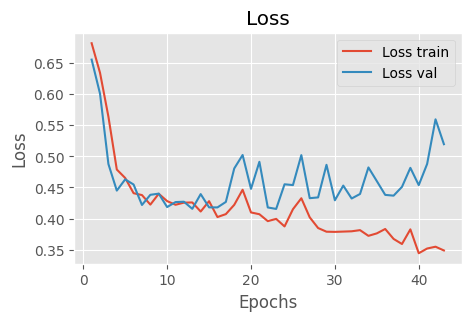

In [31]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,len(loss_val)+1), loss_train)
plt.plot(np.arange(1,len(loss_val)+1), loss_val)
plt.title('Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Loss train', 'Loss val'])
plt.show()

In [33]:
stt_model.load_state_dict(early_stopping.best_model_state)

<All keys matched successfully>

In [36]:
y_true,y_preds = src.testing.evaluate_model(stt_model,test_dataloader,device,binary_class_state)

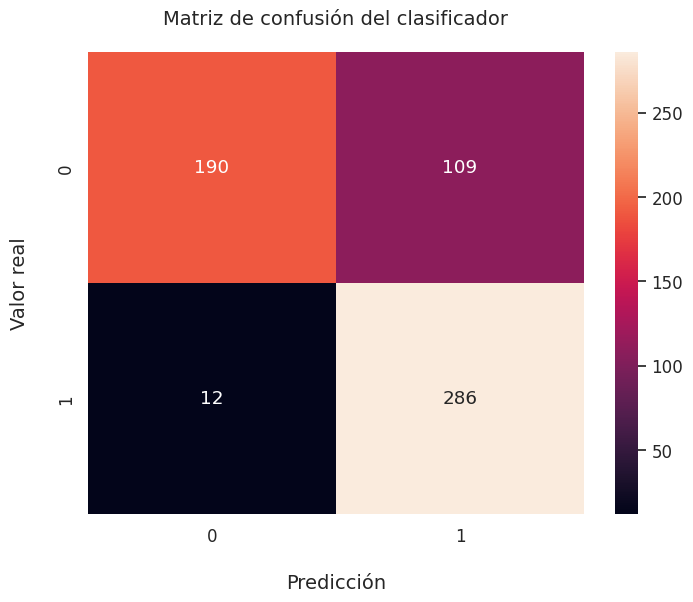

In [37]:
y_true = y_true.numpy()
y_preds = y_preds.numpy()
src.testing.plot_confussion_matrix(y_true,y_preds)

In [40]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

         0.0       0.94      0.64      0.76       299
         1.0       0.72      0.96      0.83       298

    accuracy                           0.80       597
   macro avg       0.83      0.80      0.79       597
weighted avg       0.83      0.80      0.79       597



In [41]:
y_true,y_preds = src.testing.evaluate_model(stt_model,train_dataloader,device,binary_class_state)
train_acc = balanced_accuracy_score(y_true, y_preds)

y_true,y_preds = src.testing.evaluate_model(stt_model,val_dataloader,device,binary_class_state)
val_acc = balanced_accuracy_score(y_true, y_preds)

y_true,y_preds = src.testing.evaluate_model(stt_model,test_dataloader,device,binary_class_state)
test_acc = balanced_accuracy_score(y_true, y_preds)

print('train_acc: ', train_acc, 'val_acc: ', val_acc,'test_acc: ', test_acc)

train_acc:  0.8181418551812704 val_acc:  0.8138075313807531 test_acc:  0.7975915243204417
